In [ ]:
import os
os._exit(00)

: 

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

# import local libraries
import src.utils.config as config
import proc.process_behavior_signals as pbs
# import proc.organize as org
import src.utils.data_io as dio
import src.utils.pdata_io as pdio
import numpy as np

print(config.PROJECT_ROOT)
print(config.RAW_BASE)
print(config.PROC_BASE)

import sys
from pathlib import Path

CODE_BASE = Path(config.CODE_BASE).expanduser()
sys.path.append(str(CODE_BASE))

print("Added to path:", CODE_BASE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/nmldata2/ccaw/Python
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning
Added to path: /home/nmldata2/ccaw/Python


In [3]:
# make the data dictionary which contains list of all animals and sessions and
# file names of videos h264 and mat files

data_root = config.RAW_BASE
cc_data = dio.build_classical_conditioning_dict(data_root)
pdata_root = config.PROC_BASE
print(data_root)
print(cc_data)

/mnt/data/Classical_Conditioning
{'NML_04': {'2025_12_27': {'face': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/face_1440x1080_60_20251227_154519.h264', 'pupi': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/pupi_320x240_60_20251227_154519.h264', 'video': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/video_20251227_154511.h264', 'recording': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27/recording_20251227_154502.mat', 'phase': 'habituation', 'path': '/mnt/data/Classical_Conditioning/NML_04/2025_12_27'}, '2025_12_28': {'face': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/face_1440x1080_60_20251228_154642.h264', 'pupi': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/pupi_320x240_60_20251228_154642.h264', 'video': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/video_20251228_154758.h264', 'recording': '/mnt/data/Classical_Conditioning/NML_04/2025_12_28/recording_20251228_154611.mat', 'phase': 'habituation', 'path': '/mnt/data/Classical_Conditionin

In [ ]:
# import sys
# print("\n".join(sys.path))
# Ran only once to organize the mp4 files that were already genearated
# org.organize_mp4s_from_ccdata(
#     cc_data,
#     proc_base=config.PROC_BASE,
#     dry_run=False  # ← FIRST RUN SAFE
# )

In [4]:
cfg = config.load_config()

animal = "NML_04"
date   = "2026_01_12"

mp4_dir = pdio.get_mp4_dir(animal, date)
beh_dir = pdio.get_behavior_dir(animal, date)

print(mp4_dir)
print(beh_dir)

/mnt/pdata/Classical_Conditioning/NML_04/2026_01_12/mp4
/mnt/pdata/Classical_Conditioning/NML_04/2026_01_12/behavior


In [12]:
results = pbs.process_cc_data(
    cc_data,
    animals={"NML_04"},
    phase="air_training",
    dates={"2026_01_13"},
    overwrite=True,
)

[PROCESS] NML_04 2026_01_13
DEBUG loading: /mnt/data/Classical_Conditioning/NML_04/2026_01_13/recording_20260113_152756.mat


In [74]:
results = pbs.process_cc_data(
    cc_data,
    animals={"NML_04"},
    phase="air_training",
    dates={"2026_01_12","2026_01_13","2026_01_14"},
    overwrite=True,
)

[PROCESS] NML_04 2026_01_12
DEBUG loading: /mnt/data/Classical_Conditioning/NML_04/2026_01_12/recording_20260112_161549.mat
[PROCESS] NML_04 2026_01_13
DEBUG loading: /mnt/data/Classical_Conditioning/NML_04/2026_01_13/recording_20260113_152756.mat
[PROCESS] NML_04 2026_01_14
DEBUG loading: /mnt/data/Classical_Conditioning/NML_04/2026_01_14/recording_20260114_161058.mat


In [ ]:
results = pbs.process_cc_data(
    cc_data,
    animals={"NML_04","NML_05","NML_06"},
    phase="air_training",
    dates={"2026_01_12","2026_01_13","2026_01_14"},
    overwrite=True,
)

In [ ]:
results = pbs.process_cc_data(
    cc_data,
    animals={"NML_04","NML_05","NML_06"},
    phase="air_training",
    date_min="2026_01_12",
    date_max="2026_01_18",
    overwrite=False,
)

In [6]:
b = results["NML_04"]["2026_01_12"]

# print(b["speed_net_cms"][:10])
print(len(b["Air_r"]), len(b["Air_f"]))

b = results["NML_04"]["2026_01_12"]

print("Air_r shape:", np.asarray(b["Air_r"]).shape, "dtype:", np.asarray(b["Air_r"]).dtype)
print("Air_f shape:", np.asarray(b["Air_f"]).shape, "dtype:", np.asarray(b["Air_f"]).dtype)

print("len Air_r:", len(b["Air_r"]))
print("size Air_r:", np.asarray(b["Air_r"]).size)

print("First few Air_r:", np.asarray(b["Air_r"]).ravel()[:10])
print("First few Air_f:", np.asarray(b["Air_f"]).ravel()[:10])


durations = b["Air_f"] - b["Air_r"]

print("min duration:", durations.min())
print("median duration:", np.median(durations))
print("max duration:", durations.max())

58 58
Air_r shape: (58,) dtype: int64
Air_f shape: (58,) dtype: int64
len Air_r: 58
size Air_r: 58
First few Air_r: [ 99782 195327 281824 366433 452546 584248 665804 750633 831222 919156]
First few Air_f: [ 119895  206396  291001  377115  508819  590374  675203  755794  843722
 1013895]
min duration: 5069
median duration: 27757.5
max duration: 123112


In [20]:
b = results["NML_04"]["2026_01_13"]

Air_r = b["Air_r"]
Air_f = b["Air_f"]
dist = b["dist_path_cm"]   # IMPORTANT: use path distance

# dist = b["trial_forward_cm"]   # IMPORTANT: use path distance

trial_dist_cm = dist[Air_f] - dist[Air_r]

print("First few distances (cm):", trial_dist_cm[:10])
print("min:", trial_dist_cm.min())
print("median:", np.median(trial_dist_cm))
print("max:", trial_dist_cm.max())

First few distances (cm): [50.34088068 12.71716706 12.16424675  4.97628276  6.60991094  5.0014155
  7.59008785 12.64176884  5.12707921 19.35221075]
min: 4.976282763286235
median: 6.986902061583805
max: 50.34088068112285


/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


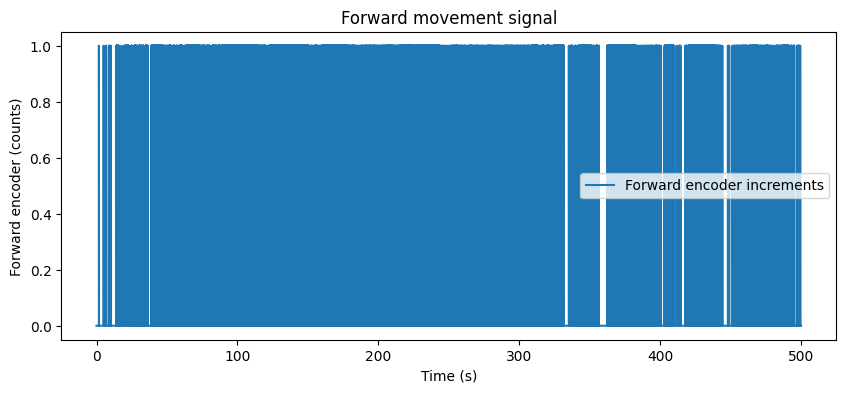

In [31]:

enc = b["encoderCount"].astype(float)
fs  = b["fs"]

# encoder increments
dEnc = np.diff(enc, prepend=enc[0])

# Arduino behavior: clamp negatives to zero
dEnc_forward = np.maximum(dEnc, 0)
fig, ax = plt.subplots(figsize=(10, 4))

t = b["t"]
air = b["air_bin"].astype(float)

# --- time window ---
tlim = (0, 500)
mask = (t >= tlim[0]) & (t <= tlim[1])

t_plot = t[mask]
dEnc_plot = dEnc_forward[mask]

ax.plot(t_plot, dEnc_plot, label="Forward encoder increments")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Forward encoder (counts)")
ax.set_title("Forward movement signal")
ax.legend()
plt.show()

In [16]:
b = results["NML_04"]["2026_01_13"]

print("Number of trials:", len(b["trial_forward_cm"]))
print("First 10 forward distances (cm):")
print(b["trial_forward_cm"])

print("Min / Median / Max:")
print(np.min(b["trial_forward_cm"]),
      np.median(b["trial_forward_cm"]),
      np.max(b["trial_forward_cm"]))

Number of trials: 55
First 10 forward distances (cm):
[16.48707825  7.0120348   6.5847782   4.97628276  5.45380485  4.97628276
  5.65486678  8.79645943  5.05168099 12.16424675  4.97628276  6.38371627
  6.50937998  7.4392914   5.25274292  7.94194623  5.93132693  6.10725612
  5.55433581  5.15221195  5.32814114  5.45380485  5.15221195  5.42867211
  5.55433581  6.05699064  5.47893759  4.97628276  6.76070739  5.62973404
  5.25274292  5.85592871  6.08212338  5.15221195  5.12707921  6.03185789
  5.57946855  5.07681373  5.20247743  5.12707921  5.50407033  6.8863711
  5.55433581  6.13238886  4.97628276  4.97628276  5.93132693  4.97628276
  6.38371627  7.59008785  6.8863711   6.66017643  6.48424724  6.60991094
  7.18796399]
Min / Median / Max:
4.976282763286232 5.62973403523291 16.487078246039236


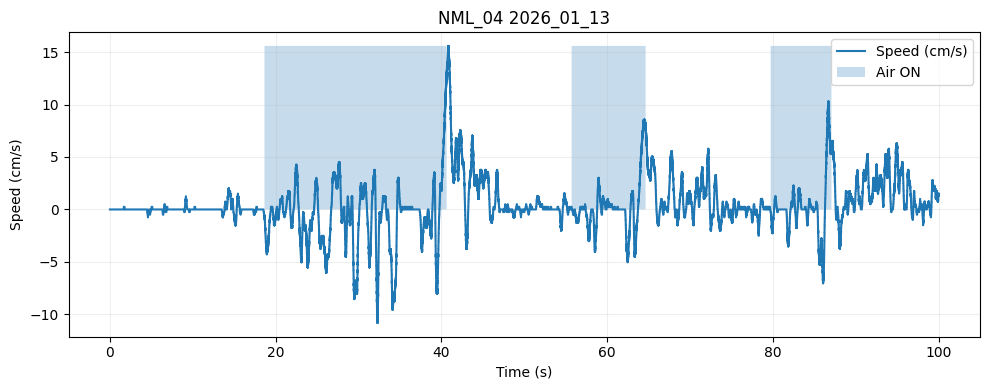

In [18]:
from vis.plots import quick_plot

quick_plot(results, "NML_04", "2026_01_13", tlim=(0,100))


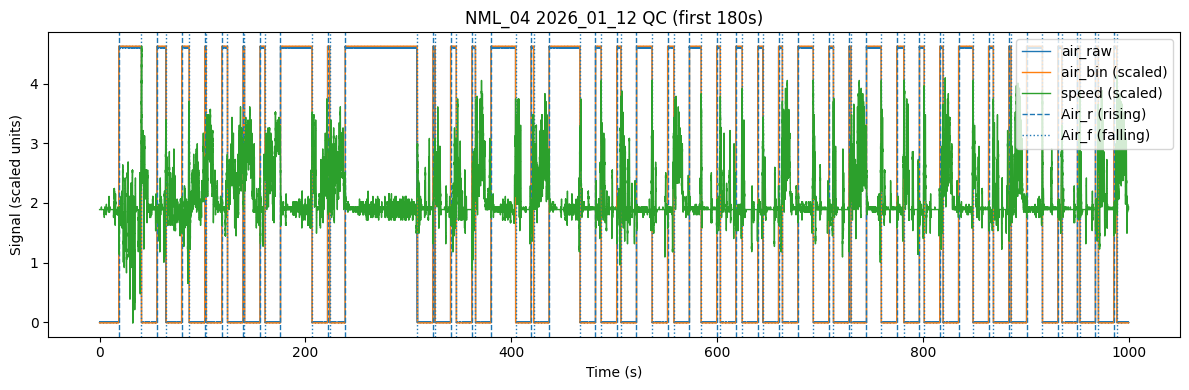

In [14]:
import matplotlib.pyplot as plt
from vis.qc_air_edges import qc_plot_air_edges

b = results["NML_04"]["2026_01_13"]
qc_plot_air_edges(b, max_seconds=1000, overlay_speed=True,
                  title="NML_04 2026_01_12 QC (first 180s)")
plt.show()

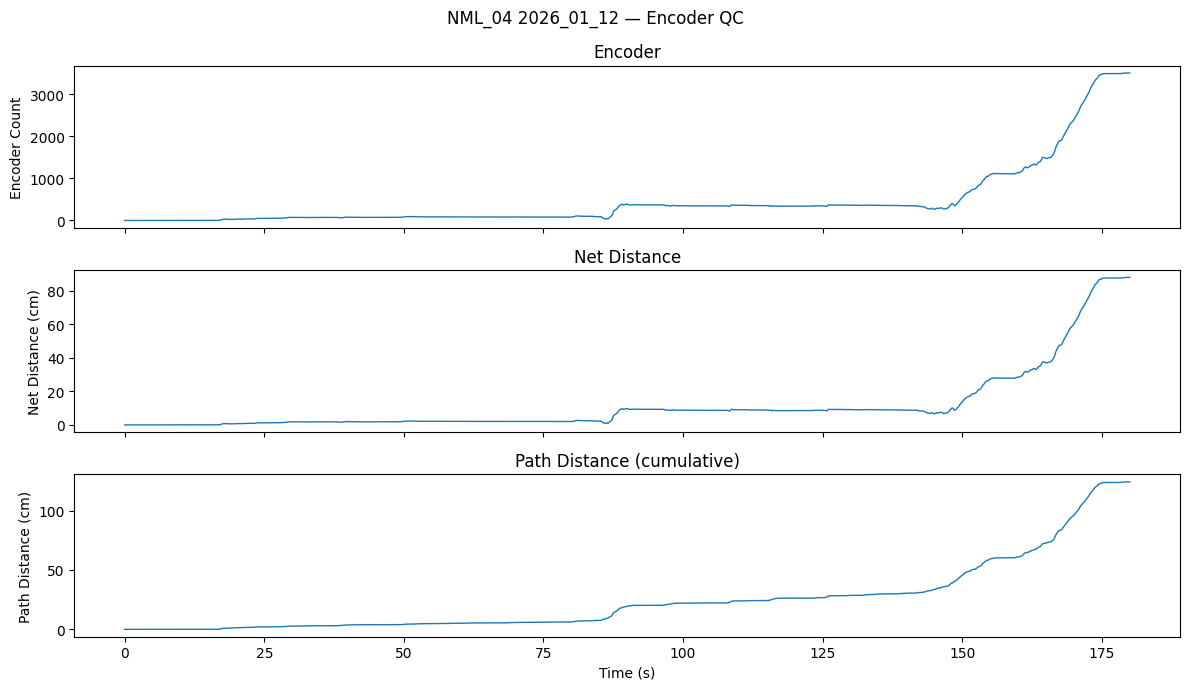

In [62]:
from vis.qc_encoder_distance import qc_plot_encoder_distance

b = results["NML_04"]["2026_01_16"]

qc_plot_encoder_distance(
    b,
    max_seconds=180,
    title="NML_04 2026_01_12 — Encoder QC"
)

plt.show()

<b> Calculating the Air Modulation Index </b>
We are going to find the air modulation index as
AMI=(SON​−SOFF​​)/(SON​+SOFF​+ϵ)
Where: SON  = mean speed during air, SOFF = mean speed in pre-air baseline window, bounded between −1 and +1 robust to scaling differences


In [13]:
from proc.ami import summarize_session_ami

animals = ["NML_04", "NML_05", "NML_06"]

ami_results = {}

for animal in animals:
    ami_results[animal] = {}

    for date, session in cc_data[animal].items():

        if session["phase"] != "air_training":
            continue

        b = results[animal][date]

        summary = summarize_session_ami(b)

        if summary is not None:
            ami_results[animal][date] = summary

DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1
DEBUG: 1


In [92]:
# print(results['NML_04']['2026_01_12'])
for date, session in cc_data[animal].items():
    print(date,session['phase'])


2025_12_27 habituation
2025_12_28 habituation
2025_12_29 habituation
2025_12_30 habituation
2025_12_31 habituation
2026_01_01 habituation
2026_01_02 habituation
2026_01_03 habituation
2026_01_04 habituation
2026_01_05 habituation
2026_01_06 habituation
2026_01_07 habituation
2026_01_08 habituation
2026_01_09 habituation
2026_01_10 habituation
2026_01_11 habituation
2026_01_12 air_training
2026_01_13 air_training
2026_01_14 air_training
2026_01_15 air_training
2026_01_16 air_training
2026_01_17 air_training
2026_01_18 air_training
2026_01_20 air_training
2026_01_21 air_training
2026_01_22 air_training
2026_01_23 air_training
2026_01_24 air_training
2026_01_25 air_training
2026_01_26 air_training
2026_01_27 air_training
2026_01_28 unknown
2026_01_29 unknown
2026_01_30 unknown
2026_01_31 unknown
2026_02_01 unknown
2026_02_02 unknown
2026_02_03 unknown
2026_02_04 unknown
2026_02_05 unknown
2026_02_06 unknown
2026_02_07 unknown
2026_02_08 unknown
2026_02_09 unknown
2026_02_10 unknown
2026_0

In [2]:

import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]